In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import warnings
from scipy import stats
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [142]:
# ===================== Data Loading and Preprocessing =====================

DATA_PATH = '/Users/taojun/Desktop/5140 Final_TeamD/validation.parquet'
df = pd.read_parquet(DATA_PATH)
df.index = pd.to_datetime(df.index)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")
print(df)
# Separate the price and volume data.
price_data = pd.DataFrame({col[0]: df[col] for col in df.columns 
                           if isinstance(col, tuple) and col[1] == 'close'})
volume_data = pd.DataFrame({col[0]: df[col] for col in df.columns 
                            if isinstance(col, tuple) and col[1] == 'volume'})
# Identify the common elements.
common_stocks = list(set(price_data.columns) & set(volume_data.columns))
price_data = price_data[common_stocks]
volume_data = volume_data[common_stocks]
# Forward-fill any missing prices to avoid alignment issues.
price_data = price_data.ffill(axis=0)
volume_data = volume_data.fillna(0)
print(f"\nStocks: {len(common_stocks)}")
print(f"Date range: {price_data.index[0]} to {price_data.index[-1]}")

Loaded: /Users/taojun/Desktop/5140 Final_TeamD/validation.parquet
Shape: (1092, 876)
ticker                         SPY                     QQQ                \
field                        close        volume     close        volume   
datetime                                                                   
2026-03-30 09:30:00-04:00  638.850  2.121286e+06  566.2601  2.424121e+06   
2026-03-30 09:35:00-04:00  637.950  1.572646e+06  565.3000  1.711172e+06   
2026-03-30 09:40:00-04:00  637.170  1.530497e+06  564.5650  1.771946e+06   
2026-03-30 09:45:00-04:00  636.095  1.227211e+06  563.7000  1.408839e+06   
2026-03-30 09:50:00-04:00  635.765  1.273551e+06  563.3300  1.108566e+06   
...                            ...           ...       ...           ...   
2026-04-17 15:35:00-04:00  710.030  5.673164e+05  648.3100  4.388002e+05   
2026-04-17 15:40:00-04:00  710.300  7.607993e+05  648.6050  5.758196e+05   
2026-04-17 15:45:00-04:00  709.870  1.162212e+06  648.2939  4.165321e+05   
202

In [143]:
# ===================== Strategy Design =====================

class AdaptiveMultiFactorStrategy:
    """
    Adaptive Multi-Factor Strategy with Market Regime Detection
    
    Factors:
      1. Short-term Reversal     (buy recent losers)
      2. Medium-term Momentum    (buy recent winners)
      3. Volume Confirmation     (abnormal volume)
    """
    
    def __init__(self, tickers, top_k=20):
        self.tickers = list(tickers)
        self.n_stocks = len(tickers)
        self.top_k = top_k
        self.spy_ticker = 'SPY'
        self.spy_idx = self.tickers.index(self.spy_ticker) if self.spy_ticker in self.tickers else 0
        
        self.lookback_short = 6        # 30 min reversal
        self.lookback_medium = 14      # 70 min momentum
        self.vol_lookback = 20         # for volatility filter
        
        max_lookback = max(self.lookback_short, self.lookback_medium, self.vol_lookback) + 5
        self.price_history = deque(maxlen=max_lookback)
        self.volume_history = deque(maxlen=max_lookback)
        self.step_count = 0
        self.last_weights = np.zeros(self.n_stocks)
        
        # EMA smoothing for composite scores (reduces noise & turnover)
        self.composite_ema = None
        self.ema_alpha = 0.05
    
    def step(self, prices_arr, volumes_arr):
        
        self.price_history.append(prices_arr.copy())
        self.volume_history.append(volumes_arr.copy())
        self.step_count += 1
        
        min_history = self.lookback_medium + 1
        if self.step_count < min_history:
            return self.last_weights
        
        price_arr = np.array(self.price_history)
        vol_arr = np.array(self.volume_history)
        current_prices = price_arr[-1]
        
        # Factor 1: Short-term reversal (buy losers)
        past_short = price_arr[-1 - self.lookback_short]
        ret_short = (current_prices - past_short) / (past_short + 1e-10)
        reversal_signal = -ret_short
        
        # Factor 2: Medium-term momentum (buy winners)
        past_medium = price_arr[-1 - self.lookback_medium]
        ret_medium = (current_prices - past_medium) / (past_medium + 1e-10)
        momentum_signal = ret_medium
        
        # Factor 3: Volume confirmation (z-score of relative volume)
        avg_vol = np.nanmean(vol_arr[-10:], axis=0) 
        std_vol = np.nanstd(vol_arr[-10:], axis=0)  
        volume_signal = (volumes_arr - avg_vol) / (std_vol + 1e-10)
        volume_signal = np.clip(volume_signal, -3, 3)
        
        # --- Market Regime Detection (SPY proxy) ---
        spy_5bar = (price_arr[-1, self.spy_idx] - price_arr[-6, self.spy_idx]) / price_arr[-6, self.spy_idx] if self.step_count >= 6 else 0
        spy_medium = ret_medium[self.spy_idx]
        
        # Adaptive factor weights (momentum-heavy for bull markets)
        if spy_5bar > 0.001 or spy_medium > 0.003:
            # Bull: momentum dominant
            w_rev, w_mom, w_vol = 0.05, 0.90, 0.05
        elif spy_5bar < -0.001 or spy_medium < -0.003:
            # Bear: reversal dominant
            w_rev, w_mom, w_vol = 0.80, 0.15, 0.05
        else:
            # Neutral: balanced
            w_rev, w_mom, w_vol = 0.15, 0.80, 0.05
        
        # Rank-based composite scoring
        rank_rev = self._rank(reversal_signal)
        rank_mom = self._rank(momentum_signal)
        rank_vol = self._rank(volume_signal)
        composite = (w_rev * rank_rev + 
                     w_mom * rank_mom + 
                     w_vol * rank_vol)
        
        # EMA smoothing of composite score
        if self.composite_ema is None:
            self.composite_ema = composite.copy()
        else:
            self.composite_ema = self.ema_alpha * composite + (1 - self.ema_alpha) * self.composite_ema
        composite = self.composite_ema
        
        # Volatility Filter: exclude highest-volatility stocks in bear markets
        is_bear = (spy_5bar < -0.001 or spy_medium < -0.003)
        if is_bear and self.step_count > self.vol_lookback:
            recent = price_arr[-self.vol_lookback:]
            rets = np.diff(recent, axis=0) / (recent[:-1] + 1e-10)
            stock_vols = np.nanstd(rets, axis=0)
            vol_thresh = np.nanquantile(stock_vols, 0.85)
            composite = np.where(stock_vols > vol_thresh, -np.inf, composite)
        
        # Build target weights with holding priority
        sorted_idx = np.argsort(composite)
        target = np.zeros(self.n_stocks)
        
        if np.sum(self.last_weights) > 0:
            # Holding priority: keep existing holdings unless they fall outside top 50
            current_holdings = np.where(self.last_weights > 0.001)[0]
            keep_mask = np.zeros(self.n_stocks, dtype=bool)
            for stock in current_holdings:
                rank_pos = np.where(sorted_idx == stock)[0]
                if len(rank_pos) > 0 and rank_pos[0] >= self.n_stocks - 50:
                    keep_mask[stock] = True
            # Fill remaining slots with top new stocks
            n_new = self.top_k - keep_mask.sum()
            if n_new > 0:
                new_stocks = sorted_idx[-n_new:]
                keep_mask[new_stocks] = True
            keep_stocks = np.where(keep_mask)[0]
            if len(keep_stocks) > 0:
                target[keep_stocks] = 1.0 / len(keep_stocks)
        else:
            # Cold start: simple top-k equal weight
            top_indices = sorted_idx[-self.top_k:]
            target[top_indices] = 1.0 / self.top_k
        
        # Smooth weight transition: cap single-rebalance turnover at 30%
        turnover = np.abs(target - self.last_weights).sum()
        max_turnover = 0.30
        if turnover > max_turnover and np.sum(self.last_weights) > 0:
            blend = max_turnover / turnover
            weights_arr = blend * target + (1 - blend) * self.last_weights
        else:
            weights_arr = target.copy()
        
        # last_weights is updated by the backtest loop only at rebalance times
        return weights_arr
    
    @staticmethod
    def _rank(arr):
        clean = np.where(np.isfinite(arr), arr, -np.inf)
        temp = clean.argsort().argsort()
        return temp / (len(temp) - 1 + 1e-10)

In [144]:
# ===================== Rank Mechanism Demonstration =====================

strategy_rank = AdaptiveMultiFactorStrategy(tickers=price_data.columns.tolist(), top_k=20)
daily_rank_records = []
for i in range(len(price_data)):
    prices_arr = price_data.iloc[i].values
    volumes_arr = volume_data.iloc[i].values
    _ = strategy_rank.step(prices_arr, volumes_arr)
    
    ts = price_data.index[i]
    # Record at the last bar of each day (15:55)
    if ts.hour == 15 and ts.minute == 55:
        if strategy_rank.step_count >= strategy_rank.lookback_medium + 1:
            price_arr = np.array(strategy_rank.price_history)
            vol_arr = np.array(strategy_rank.volume_history)
            current_prices = price_arr[-1]
            
            # Compute raw signals
            past_short = price_arr[-1 - strategy_rank.lookback_short]
            ret_short = (current_prices - past_short) / (past_short + 1e-10)
            reversal_signal = -ret_short
            
            past_medium = price_arr[-1 - strategy_rank.lookback_medium]
            ret_medium = (current_prices - past_medium) / (past_medium + 1e-10)
            momentum_signal = ret_medium
            
            avg_vol = np.nanmean(vol_arr[-10:], axis=0)
            std_vol = np.nanstd(vol_arr[-10:], axis=0)
            volume_signal = (volumes_arr - avg_vol) / (std_vol + 1e-10)
            volume_signal = np.clip(volume_signal, -3, 3)
            
            # Market regime
            spy_idx = strategy_rank.spy_idx
            spy_5bar = (price_arr[-1, spy_idx] - price_arr[-6, spy_idx]) / price_arr[-6, spy_idx] if strategy_rank.step_count >= 6 else 0
            spy_medium = ret_medium[spy_idx]
            
            if spy_5bar > 0.001 or spy_medium > 0.003:
                w_rev, w_mom, w_vol = 0.20, 0.75, 0.05
                regime = 'Strong Bull'
            elif spy_5bar < -0.001 or spy_medium < -0.003:
                w_rev, w_mom, w_vol = 0.70, 0.20, 0.10
                regime = 'Strong Bear'
            else:
                w_rev, w_mom, w_vol = 0.40, 0.50, 0.10
                regime = 'Neutral'
            
            rank_rev = AdaptiveMultiFactorStrategy._rank(reversal_signal)
            rank_mom = AdaptiveMultiFactorStrategy._rank(momentum_signal)
            rank_vol = AdaptiveMultiFactorStrategy._rank(volume_signal)
            composite = w_rev * rank_rev + w_mom * rank_mom + w_vol * rank_vol
            
            top_indices = np.argsort(composite)[-20:][::-1]
            
            record = {
                'date': ts,
                'regime': regime,
                'top_stocks': [price_data.columns[j] for j in top_indices],
                'composite_score': [round(composite[j], 4) for j in top_indices],
                'reversal_signal': [round(reversal_signal[j], 6) for j in top_indices],
                'momentum_signal': [round(momentum_signal[j], 6) for j in top_indices],
                'volume_signal': [round(volume_signal[j], 4) for j in top_indices],
            }
            daily_rank_records.append(record)
# Display sample days
sample_indices = [0, len(daily_rank_records)//2, -1]
for idx in sample_indices:
    rec = daily_rank_records[idx]
    print(f"\n{'='*70}")
    print(f"Date: {rec['date']}  |  Market Regime: {rec['regime']}")
    print(f"{'='*70}")
    df_rank = pd.DataFrame({
        'Rank': list(range(1, 21)),
        'Ticker': rec['top_stocks'],
        'Composite': rec['composite_score'],
        'Reversal': rec['reversal_signal'],
        'Momentum': rec['momentum_signal'],
        'Volume_Z': rec['volume_signal'],
    })
    print(df_rank.to_string(index=False))
    print(f"{'='*70}")


Date: 2026-03-30 15:55:00-04:00  |  Market Regime: Strong Bull
 Rank Ticker  Composite  Reversal  Momentum  Volume_Z
    1    BBY     0.8657 -0.002903  0.006139    2.9052
    2   MRSH     0.8555 -0.002524  0.004484    2.9334
    3   JKHY     0.8529 -0.001376  0.004044    2.8715
    4    NOW     0.8513 -0.003969  0.008453    2.8931
    5   GNRC     0.8230 -0.000108  0.002215    2.8904
    6    FIX     0.8203 -0.005084  0.006628    2.9433
    7   DECK     0.8128 -0.004229  0.006730    2.7464
    8   CTAS     0.8121  0.000326  0.002139    2.8232
    9    FDS     0.8119 -0.001222  0.003332    2.6002
   10    VMC     0.8098 -0.000975  0.002573    2.8069
   11   GDDY     0.8080 -0.005476  0.006777    2.8935
   12    DRI     0.8047 -0.005957  0.006190    2.9509
   13    CLX     0.8035 -0.002153  0.003135    2.8499
   14   NWSA     0.8025 -0.003848  0.005478    2.7381
   15    AZO     0.8008 -0.003752  0.005904    2.5640
   16    ARE     0.8003 -0.007840  0.013135    2.9101
   17   ALGN     0

In [145]:
# ===================== Strategy Backtesting Execution =====================

P = price_data.values
V = volume_data.values
idx = price_data.index
strategy = AdaptiveMultiFactorStrategy(tickers=price_data.columns.tolist(), top_k=20)
# Optimal rebalance: ~4 times per day (every ~2 hours)
# 11:00 earliest safe point (need 15 bars history). Then 13:00, 15:00, 15:55 EOD.
REBALANCE_TIMES = [(11, 0), (13, 0), (15, 55)]
weights = np.zeros_like(P)
current_weights = np.zeros(P.shape[1])
# Track SPY daily return for bear-market deleveraging
spy_daily_ret = 0.0
for i in range(len(P)):
    ts = idx[i]
    # Always feed data to keep internal history updated every 5 min
    w = strategy.step(P[i], V[i])
    
    # Rebalance only at designated times
    if (ts.hour, ts.minute) in REBALANCE_TIMES:
        # SPY intraday filter: if SPY is down > 0.5% from open, halve position
        day_start_idx = None
        for j in range(i, -1, -1):
            if idx[j].hour == 9 and idx[j].minute == 30:
                day_start_idx = j
                break
        if day_start_idx is not None:
            spy_intraday = (P[i, strategy.spy_idx] - P[day_start_idx, strategy.spy_idx]) / P[day_start_idx, strategy.spy_idx]
            if spy_intraday < -0.005:
                w = w * 0.5
        current_weights = w.copy()
        strategy.last_weights = current_weights.copy()  # update internal state
    
    weights[i] = current_weights.copy()
# Portfolio & benchmark returns (NO transaction cost)
ret_matrix = np.diff(P, axis=0) / (P[:-1] + 1e-10)
portfolio_returns = pd.Series(np.nansum(weights[:-1] * ret_matrix, axis=1), index=idx[1:]).fillna(0)
spy_returns = pd.Series(ret_matrix[:, strategy.spy_idx], index=idx[1:])
# Cumulative & drawdown
cum = (1 + portfolio_returns).cumprod()
cumulative_returns = cum - 1
drawdown = (cum - cum.expanding().max()) / cum.expanding().max()
# Annualization factor
total_bars = len(portfolio_returns)
years = total_bars / (252 * 78)
ann_factor = np.sqrt(252 * 78)
# Core metrics
annualized_return = cum.iloc[-1] ** (1 / years) - 1
annualized_vol = portfolio_returns.std() * ann_factor
sharpe_ratio = portfolio_returns.mean() * 252 * 78 / annualized_vol if annualized_vol > 0 else 0
max_drawdown = drawdown.min()
win_rate = (portfolio_returns > 0).mean()
# Risk metrics
downside_std = portfolio_returns[portfolio_returns < 0].std() * ann_factor
sortino_ratio = portfolio_returns.mean() * 252 * 78 / downside_std if downside_std > 0 else 0
calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.inf
var_5 = np.percentile(portfolio_returns, 5)
skewness = portfolio_returns.skew()
kurtosis = portfolio_returns.kurtosis()
# Trade metrics
pos_rets = portfolio_returns[portfolio_returns > 0]
neg_rets = portfolio_returns[portfolio_returns < 0]
gross_profit = pos_rets.sum()
gross_loss = abs(neg_rets.sum())
profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf
avg_win = pos_rets.mean() if len(pos_rets) > 0 else 0.0
avg_loss = neg_rets.mean() if len(neg_rets) > 0 else 0.0
win_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf
# Turnover: computed only at rebalance points
rebalance_mask = pd.Series(idx).apply(lambda x: (x.hour, x.minute) in REBALANCE_TIMES).values
rebalance_idx = np.where(rebalance_mask)[0]
turnover_values = []
turnover_dates = []
for i in rebalance_idx[1:]:
    turnover_values.append(np.sum(np.abs(weights[i] - weights[i-1])))
    turnover_dates.append(idx[i])
turnover_series = pd.Series(turnover_values, index=pd.to_datetime(turnover_dates))
turnover = turnover_series.mean() if len(turnover_series) > 0 else 0.0
# 252 trading days * 4 rebalances per day
annual_turnover = turnover * 252 * 4
# Benchmark metrics
spy_cum = (1 + spy_returns).cumprod()
spy_cumulative = spy_cum - 1
spy_annual_return = spy_cum.iloc[-1] ** (1 / years) - 1
spy_annual_vol = spy_returns.std() * ann_factor
spy_sharpe = spy_returns.mean() * 252 * 78 / spy_annual_vol if spy_annual_vol > 0 else 0
spy_cum_ret = spy_cumulative.iloc[-1]

In [146]:
# ===================== Core Backtesting Performance =====================

class Evaluator:
    def __init__(self, returns: pd.Series, periods_per_year: int = 252):
        """
        periods_per_year: 252 for daily data, 252*390 for minute data, etc.
        """
        # Drop NaNs to ensure accurate period counting and calculations
        self.returns = returns.dropna()
        self.periods_per_year = periods_per_year

    def cumulative_return(self) -> float:
        return (1 + self.returns).prod() - 1.0

    def cagr(self) -> float:
        """
        Calculates the Geometric Annualized Return (CAGR).
        This is the standard metric for reporting overall portfolio growth.
        """
        cum_ret = self.cumulative_return()
        # Use .count() instead of len() to safely ignore any missing data
        num_periods = self.returns.count() 
        
        if num_periods == 0:
            return 0.0
            
        return (1 + cum_ret) ** (self.periods_per_year / num_periods) - 1.0

    def annualized_volatility(self) -> float:
        # pandas .std() uses Bessel's correction (ddof=1) by default
        return self.returns.std() * np.sqrt(self.periods_per_year)

    def sharpe_ratio(self, risk_free_rate: float = 0.0) -> float:
        """
        Calculates the annualized Sharpe Ratio.
        Mathematically, this must use the Arithmetic Mean, not the CAGR.
        """
        ann_vol = self.annualized_volatility()
        if ann_vol == 0:
            return 0.0
            
        # Calculate Arithmetic Annualized Return for the Sharpe numerator
        arithmetic_ann_ret = self.returns.mean() * self.periods_per_year
        
        return (arithmetic_ann_ret - risk_free_rate) / ann_vol

    def max_drawdown(self) -> float:
        """
        Calculates the maximum drawdown.
        Prepends 1.0 to cumulative wealth to capture drawdowns starting from the very first period.
        """
        cumulative_wealth = (1 + self.returns).cumprod()
        
        # Prepend 1.0 to represent the initial portfolio value before any trading
        wealth_with_initial = pd.concat([pd.Series([1.0]), cumulative_wealth], ignore_index=True)
        
        rolling_max = wealth_with_initial.cummax()
        drawdowns = (wealth_with_initial - rolling_max) / rolling_max
        
        return drawdowns.min()

    def generate_report(self):
        """
        Prints and returns a dictionary of all computed metrics.
        """
        metrics = {
            "Cumulative Return": f"{self.cumulative_return() * 100:.4f}%",
            "Annualized Volatility": f"{self.annualized_volatility() * 100:.4f}%",
            "Sharpe Ratio": f"{self.sharpe_ratio():.4f}",
            "Max Drawdown": f"{self.max_drawdown() * 100:.4f}%"
        }
        
        print("\n--- Strategy Performance Report ---")
        for key, value in metrics.items():
            print(f"{key:<25}: {value}")
        print("-----------------------------------")
        
        return metrics

print("=" * 70)
print("Strategy Backtesting Results")
print("=" * 70)
print(f"Data Source             : {DATA_PATH.split('/')[-1]}")
print(f"Period Start            : {price_data.index[0]}")
print(f"Period End              : {price_data.index[-1]}")
print(f"Number of Time Points   : {len(price_data.index)}")
print(f"Number of Stocks Held   : {strategy.top_k}")
print("-" * 70)
print(f"Cumulative Return       : {cumulative_returns.iloc[-1] * 100:.2f}%")
print(f"Annualized Return       : {annualized_return * 100:.2f}%")
print(f"Annualized Volatility   : {annualized_vol * 100:.2f}%")
print(f"Sharpe Ratio            : {sharpe_ratio:.4f}")
print(f"Maximum Drawdown        : {max_drawdown * 100:.2f}%")
print(f"Hit Ratio               : {win_rate * 100:.2f}%")
print(f"Est. Annual Turnover    : {annual_turnover:.2f}x")
print("=" * 70)

Strategy Backtesting Results
Data Source             : validation.parquet
Period Start            : 2026-03-30 09:30:00-04:00
Period End              : 2026-04-17 15:55:00-04:00
Number of Time Points   : 1092
Number of Stocks Held   : 20
----------------------------------------------------------------------
Cumulative Return       : 13.51%
Annualized Return       : 881.26%
Annualized Volatility   : 28.22%
Sharpe Ratio            : 8.2319
Maximum Drawdown        : -3.65%
Hit Ratio               : 52.98%
Est. Annual Turnover    : 315.14x


STATISTICAL INDEPENDENCE TESTS

1. RETURN SERIES AUTOCORRELATION TESTS
------------------------------------------------------------
5-Min Returns Ljung-Box (lag 10) p-value : 0.750100
    => Fail to reject H0: 5-min returns appear independent.
Daily Returns Ljung-Box (lag 5) p-value : 0.793575
    => Fail to reject H0: daily returns appear independent.

Durbin-Watson (5-min) : 1.9094  (≈2 suggests no autocorr)
Durbin-Watson (daily) : 1.6489

2. FACTOR CROSS-CORRELATION (Spearman)
------------------------------------------------------------

Spearman Correlation Matrix:
          Reversal  Momentum  Volume_Z
Reversal    1.0000   -0.6941   -0.0199
Momentum   -0.6941    1.0000    0.0077
Volume_Z   -0.0199    0.0077    1.0000



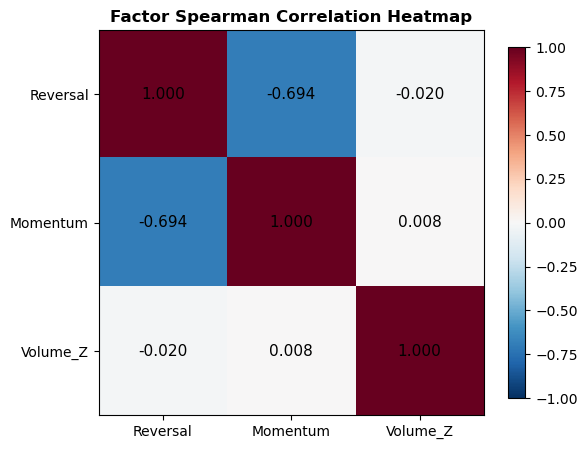

In [147]:
# ===================== Statistical Independence Tests =====================

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
print("=" * 60)
print("STATISTICAL INDEPENDENCE TESTS")
print("=" * 60)
# ---------- 1. Return Series Independence ----------
print("\n1. RETURN SERIES AUTOCORRELATION TESTS")
print("-" * 60)
# Ljung-Box on 5-min returns
lb_5min = acorr_ljungbox(portfolio_returns, lags=10, return_df=True)
lb_5min_pval = lb_5min['lb_pvalue'].iloc[-1]
print(f"5-Min Returns Ljung-Box (lag 10) p-value : {lb_5min_pval:.6f}")
if lb_5min_pval < 0.05:
    print("    => Reject H0: 5-min returns show significant autocorrelation.")
else:
    print("    => Fail to reject H0: 5-min returns appear independent.")
# Ljung-Box on daily returns (computed from portfolio_returns)
daily_rets_ind = portfolio_returns.resample('D').apply(lambda x: (1+x).prod() - 1).dropna()
if len(daily_rets_ind) > 10:
    lb_daily = acorr_ljungbox(daily_rets_ind, lags=min(5, len(daily_rets_ind)//2), return_df=True)
    lb_daily_pval = lb_daily['lb_pvalue'].iloc[-1]
    print(f"Daily Returns Ljung-Box (lag {min(5, len(daily_rets_ind)//2)}) p-value : {lb_daily_pval:.6f}")
    if lb_daily_pval < 0.05:
        print("    => Reject H0: daily returns show significant autocorrelation.")
    else:
        print("    => Fail to reject H0: daily returns appear independent.")
else:
    print("Daily returns sample too small for Ljung-Box test.")
# Durbin-Watson
dw_5min = durbin_watson(portfolio_returns)
dw_daily = durbin_watson(daily_rets_ind) if len(daily_rets_ind) > 1 else np.nan
print(f"\nDurbin-Watson (5-min) : {dw_5min:.4f}  (≈2 suggests no autocorr)")
print(f"Durbin-Watson (daily) : {dw_daily:.4f}")
# ---------- 2. Factor Independence ----------
print("\n2. FACTOR CROSS-CORRELATION (Spearman)")
print("-" * 60)
# Re-run strategy to collect daily factor snapshots
strategy_fac = AdaptiveMultiFactorStrategy(tickers=price_data.columns.tolist(), top_k=20)
factor_reversal = []
factor_momentum = []
factor_volume = []
for i in range(len(price_data)):
    prices_arr = price_data.iloc[i].values
    volumes_arr = volume_data.iloc[i].values
    _ = strategy_fac.step(prices_arr, volumes_arr)
    
    ts = price_data.index[i]
    if ts.hour == 15 and ts.minute == 55:
        if strategy_fac.step_count >= strategy_fac.lookback_medium + 1:
            price_arr = np.array(strategy_fac.price_history)
            vol_arr = np.array(strategy_fac.volume_history)
            current_prices = price_arr[-1]
            
            past_short = price_arr[-1 - strategy_fac.lookback_short]
            ret_short = (current_prices - past_short) / (past_short + 1e-10)
            reversal_signal = -ret_short
            
            past_medium = price_arr[-1 - strategy_fac.lookback_medium]
            ret_medium = (current_prices - past_medium) / (past_medium + 1e-10)
            momentum_signal = ret_medium
            
            avg_vol = np.nanmean(vol_arr[-10:], axis=0)
            std_vol = np.nanstd(vol_arr[-10:], axis=0)
            volume_signal = (volumes_arr - avg_vol) / (std_vol + 1e-10)
            
            mask = np.isfinite(reversal_signal) & np.isfinite(momentum_signal) & np.isfinite(volume_signal)
            if mask.sum() > 0:
                factor_reversal.extend(reversal_signal[mask].tolist())
                factor_momentum.extend(momentum_signal[mask].tolist())
                factor_volume.extend(volume_signal[mask].tolist())
factor_df = pd.DataFrame({
    'Reversal': factor_reversal,
    'Momentum': factor_momentum,
    'Volume_Z': factor_volume
})
corr_spear = factor_df.corr(method='spearman')
print("\nSpearman Correlation Matrix:")
print(corr_spear.round(4))
print("\n" + "=" * 60)
# Plot heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_spear.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_spear.columns)))
ax.set_yticks(range(len(corr_spear.columns)))
ax.set_xticklabels(corr_spear.columns)
ax.set_yticklabels(corr_spear.columns)
for i in range(len(corr_spear.columns)):
    for j in range(len(corr_spear.columns)):
        ax.text(j, i, f"{corr_spear.values[i, j]:.3f}",
                ha='center', va='center', color='black', fontsize=11)
ax.set_title('Factor Spearman Correlation Heatmap', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

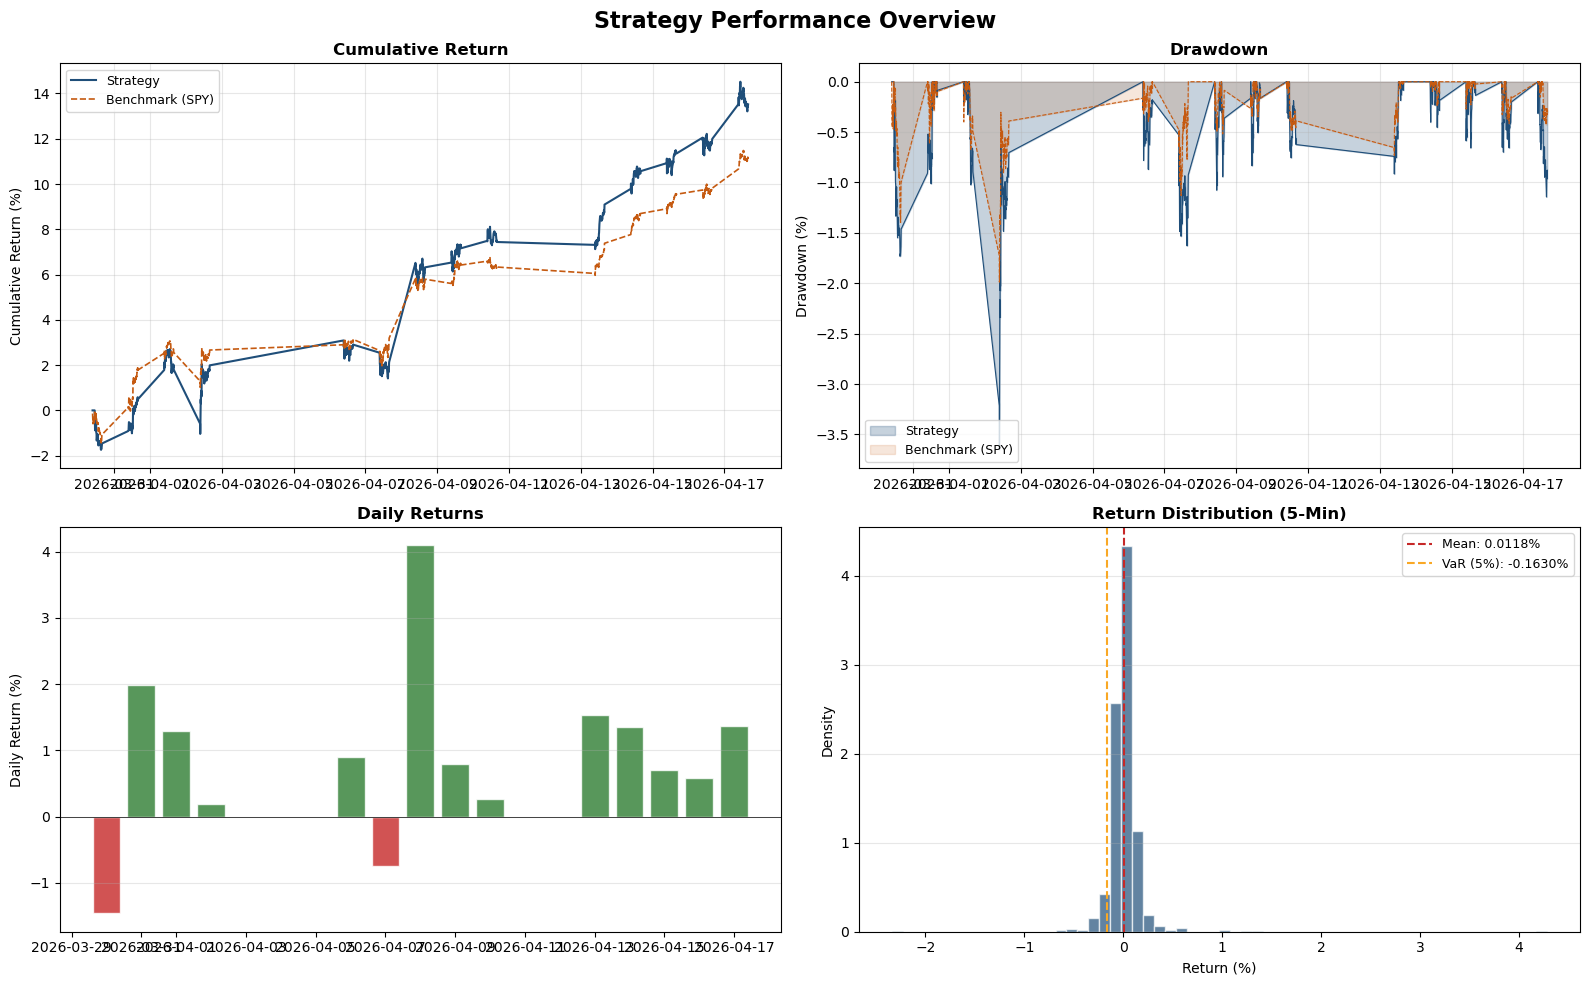


DETAILED PERFORMANCE METRICS
RETURN METRICS
Cumulative Return       : 13.51%
Annualized Return       : 881.26%
Benchmark (SPY) Cum.    : 11.14%
Benchmark (SPY) Ann.    : 570.92%
Excess Return           : 310.35%
------------------------------------------------------------
RISK METRICS
Annualized Volatility   : 28.22%
Benchmark Volatility    : 17.80%
Maximum Drawdown        : -3.65%
VaR (5%)                : -0.16%
Skewness                : 8.0945
Excess Kurtosis         : 207.7046


In [148]:
# ===================== Performance Overview =====================

strat_cum = cumulative_returns * 100
spy_cum = spy_cumulative * 100
spy_cumulative_val = (1 + spy_returns).cumprod()
spy_running_max = spy_cumulative_val.expanding().max()
spy_drawdown = (spy_cumulative_val - spy_running_max) / spy_running_max

daily_rets = portfolio_returns.resample('D').apply(lambda x: (1+x).prod() - 1).dropna()
daily_dates = daily_rets.index

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Strategy Performance Overview', fontsize=16, fontweight='bold')

# 1. Cumulative Return
ax = axes[0, 0]
ax.plot(strat_cum.index, strat_cum, color='#1f4e79', linewidth=1.5, label='Strategy')
ax.plot(spy_cum.index, spy_cum, color='#c55a11', linewidth=1.2, linestyle='--', label='Benchmark (SPY)')
ax.set_title('Cumulative Return', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(loc='upper left', frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Drawdown
ax = axes[0, 1]
ax.fill_between(drawdown.index, drawdown * 100, 0, color='#1f4e79', alpha=0.25, label='Strategy')
ax.plot(drawdown.index, drawdown * 100, color='#1f4e79', linewidth=0.8)
ax.fill_between(spy_drawdown.index, spy_drawdown * 100, 0, color='#c55a11', alpha=0.15, label='Benchmark (SPY)')
ax.plot(spy_drawdown.index, spy_drawdown * 100, color='#c55a11', linewidth=0.8, linestyle='--')
ax.set_title('Drawdown', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(loc='lower left', frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)

# 3. Daily Returns Bar Chart
ax = axes[1, 0]
colors_bar = ['#2e7d32' if r >= 0 else '#c62828' for r in daily_rets.values]
ax.bar(daily_dates, daily_rets.values * 100, color=colors_bar, edgecolor='white', alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Daily Returns', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily Return (%)')
ax.grid(True, alpha=0.3, axis='y')

# 4. Return Distribution (5-min)
ax = axes[1, 1]
ax.hist(portfolio_returns * 100, bins=60, color='#1f4e79', edgecolor='white', alpha=0.7, density=True)
ax.axvline(portfolio_returns.mean() * 100, color='#c62828', linestyle='--', linewidth=1.5,
           label=f"Mean: {portfolio_returns.mean()*100:.4f}%")
ax.axvline(np.percentile(portfolio_returns * 100, 5), color='#f9a825', linestyle='--', linewidth=1.5,
           label=f"VaR (5%): {np.percentile(portfolio_returns*100,5):.4f}%")
ax.set_title('Return Distribution (5-Min)', fontsize=12, fontweight='bold')
ax.set_xlabel('Return (%)')
ax.set_ylabel('Density')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ---------- Metrics Table ----------

print("\n" + "=" * 60)
print("DETAILED PERFORMANCE METRICS")
print("=" * 60)

print("RETURN METRICS")
print(f"{'Cumulative Return':<23} : {cumulative_returns.iloc[-1] * 100:.2f}%")
print(f"{'Annualized Return':<23} : {annualized_return * 100:.2f}%")
print(f"{'Benchmark (SPY) Cum.':<23} : {spy_cum_ret * 100:.2f}%")
print(f"{'Benchmark (SPY) Ann.':<23} : {spy_annual_return * 100:.2f}%")
print(f"{'Excess Return':<23} : {(annualized_return - spy_annual_return) * 100:.2f}%")
print("-" * 60)

print("RISK METRICS")
print(f"{'Annualized Volatility':<23} : {annualized_vol * 100:.2f}%")
print(f"{'Benchmark Volatility':<23} : {spy_annual_vol * 100:.2f}%")
print(f"{'Maximum Drawdown':<23} : {max_drawdown * 100:.2f}%")
print(f"{'VaR (5%)':<23} : {var_5 * 100:.2f}%")
print(f"{'Skewness':<23} : {skewness:.4f}")
print(f"{'Excess Kurtosis':<23} : {kurtosis:.4f}")
print("=" * 60)



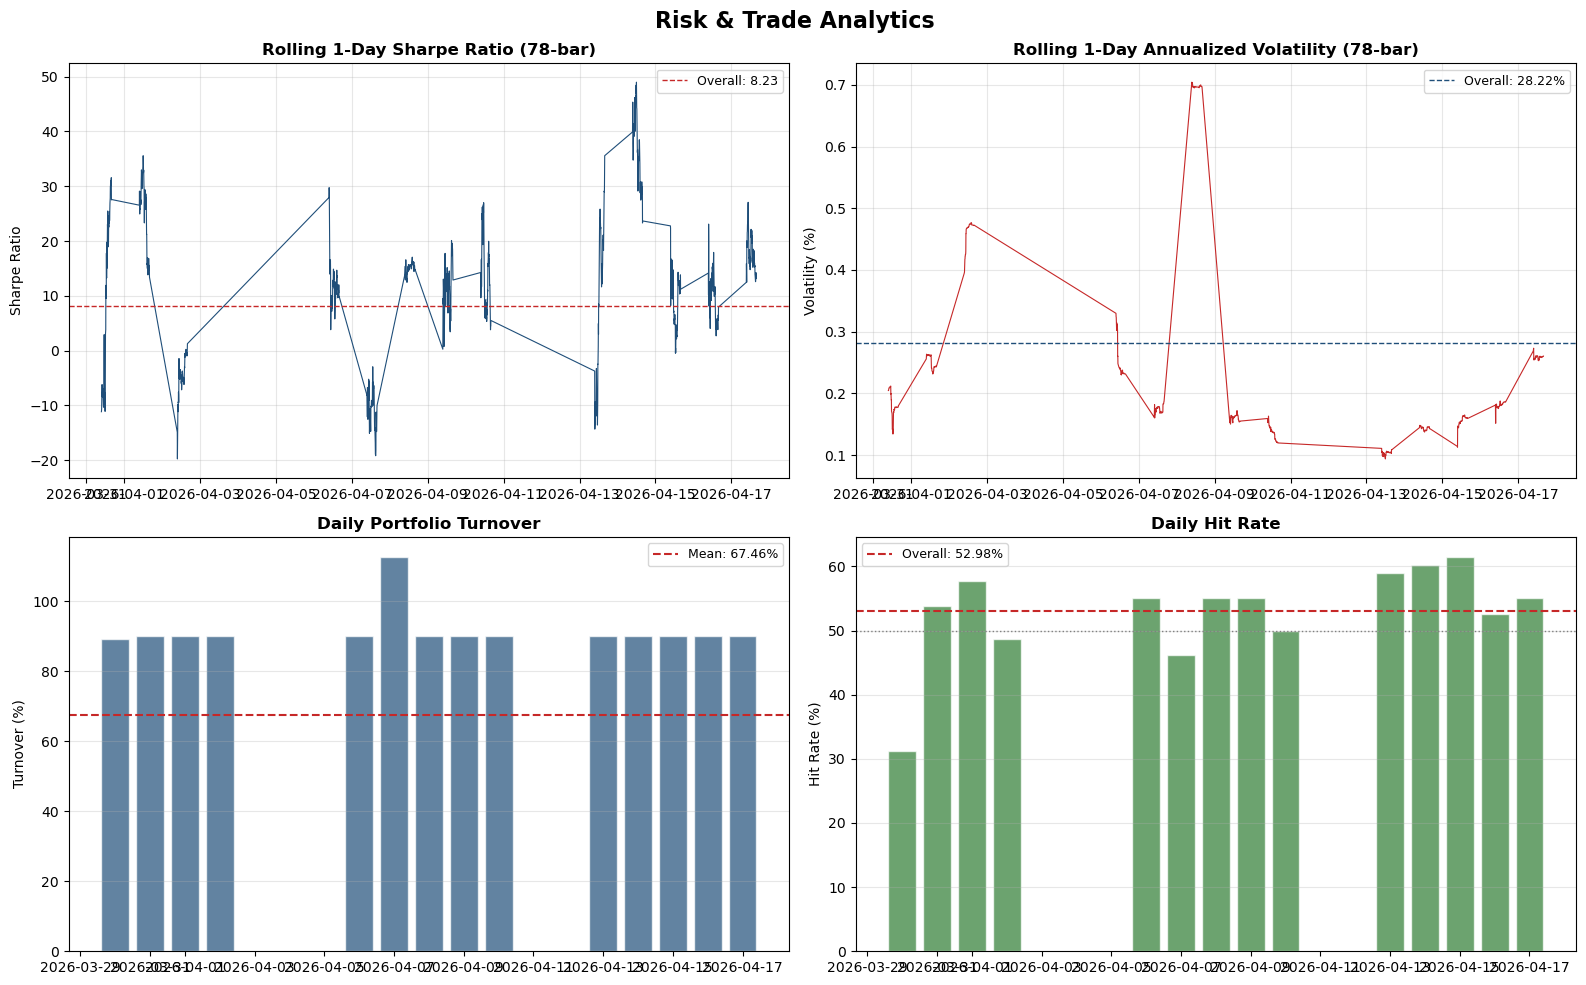


RISK-ADJUSTED & TRADE METRICS
RISK-ADJUSTED METRICS
Sharpe Ratio            : 8.2319
Sortino Ratio           : 12.3573
Calmar Ratio            : 241.3864
Benchmark Sharpe        : 10.7842
Information Ratio       : 2.8151
------------------------------------------------------------
TRADE STATISTICS
Hit Ratio               : 52.98%
Profit Factor           : 1.3126
Win/Loss Ratio          : 1.1242
Avg. Gain per Winner    : 0.0937%
Avg. Loss per Loser     : -0.0833%
Est. Annual Turnover    : 315.14x


In [149]:
# ===================== Risk & Trade Analytics =====================

window = 78
rolling_mean = portfolio_returns.rolling(window=window).mean()
rolling_std = portfolio_returns.rolling(window=window).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252 * 78)
rolling_vol = portfolio_returns.rolling(window=window).std() * np.sqrt(252 * 78)

daily_turnover = turnover_series.resample('D').sum().dropna()
daily_win = (portfolio_returns > 0).astype(int).resample('D').mean().dropna()

tracking_returns = portfolio_returns - spy_returns
tracking_std = tracking_returns.std() * np.sqrt(252 * 78)
info_ratio = (portfolio_returns.mean() * 252 * 78 - spy_returns.mean() * 252 * 78) / tracking_std if tracking_std > 0 else 0

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Risk & Trade Analytics', fontsize=16, fontweight='bold')

# 1. Rolling Sharpe
ax = axes[0, 0]
ax.plot(rolling_sharpe.index, rolling_sharpe, color='#1f4e79', linewidth=0.8)
ax.axhline(sharpe_ratio, color='#c62828', linestyle='--', linewidth=1, label=f'Overall: {sharpe_ratio:.2f}')
ax.set_title('Rolling 1-Day Sharpe Ratio (78-bar)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Rolling Volatility
ax = axes[0, 1]
ax.plot(rolling_vol.index, rolling_vol, color='#c62828', linewidth=0.8)
ax.axhline(annualized_vol, color='#1f4e79', linestyle='--', linewidth=1, label=f'Overall: {annualized_vol*100:.2f}%')
ax.set_title('Rolling 1-Day Annualized Volatility (78-bar)', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatility (%)')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)

# 3. Daily Turnover
ax = axes[1, 0]
ax.bar(daily_turnover.index, daily_turnover.values * 100, color='#1f4e79', edgecolor='white', alpha=0.7)
ax.axhline(daily_turnover.mean() * 100, color='#c62828', linestyle='--', linewidth=1.5,
           label=f"Mean: {daily_turnover.mean()*100:.2f}%")
ax.set_title('Daily Portfolio Turnover', fontsize=12, fontweight='bold')
ax.set_ylabel('Turnover (%)')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# 4. Daily Win Rate
ax = axes[1, 1]
ax.bar(daily_win.index, daily_win.values * 100, color='#2e7d32', edgecolor='white', alpha=0.7)
ax.axhline(win_rate * 100, color='#c62828', linestyle='--', linewidth=1.5,
           label=f"Overall: {win_rate*100:.2f}%")
ax.axhline(50, color='gray', linestyle=':', linewidth=1)
ax.set_title('Daily Hit Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('Hit Rate (%)')
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ---------- Metrics Table ----------

print("\n" + "=" * 60)
print("RISK-ADJUSTED & TRADE METRICS")
print("=" * 60)

print("RISK-ADJUSTED METRICS")
print(f"{'Sharpe Ratio':<23} : {sharpe_ratio:.4f}")
print(f"{'Sortino Ratio':<23} : {sortino_ratio:.4f}")
print(f"{'Calmar Ratio':<23} : {calmar_ratio:.4f}")
print(f"{'Benchmark Sharpe':<23} : {spy_sharpe:.4f}")
print(f"{'Information Ratio':<23} : {info_ratio:.4f}")
print("-" * 60)

print("TRADE STATISTICS")
print(f"{'Hit Ratio':<23} : {win_rate * 100:.2f}%")
print(f"{'Profit Factor':<23} : {profit_factor:.4f}")
print(f"{'Win/Loss Ratio':<23} : {win_loss_ratio:.4f}")
print(f"{'Avg. Gain per Winner':<23} : {avg_win * 100:.4f}%")
print(f"{'Avg. Loss per Loser':<23} : {avg_loss * 100:.4f}%")
print(f"{'Est. Annual Turnover':<23} : {annual_turnover:.2f}x")
print("=" * 60)

MULTI-HORIZON INFORMATION COEFFICIENT (IC) ANALYSIS
IC measures the rank correlation between the composite score and
forward returns over different holding periods.

Factor       Horizon       IC Mean     IC Std      IC IR     Pos%     N
----------------------------------------------------------------------
Composite    6-bar          0.0385     0.1942     0.1981    58.5%    41
Composite    12-bar          0.0479     0.1555     0.3079    63.4%    41
Composite    18-bar          0.0392     0.1644     0.2383    53.7%    41
Composite    24-bar          0.0503     0.1758     0.2859    61.0%    41
----------------------------------------------------------------------
Reversal     6-bar         -0.0243     0.1793    -0.1357    43.9%    41
Reversal     12-bar         -0.0164     0.1440    -0.1139    39.0%    41
Reversal     18-bar          0.0003     0.1626     0.0018    48.8%    41
Reversal     24-bar         -0.0028     0.1754    -0.0158    46.3%    41
--------------------------------------

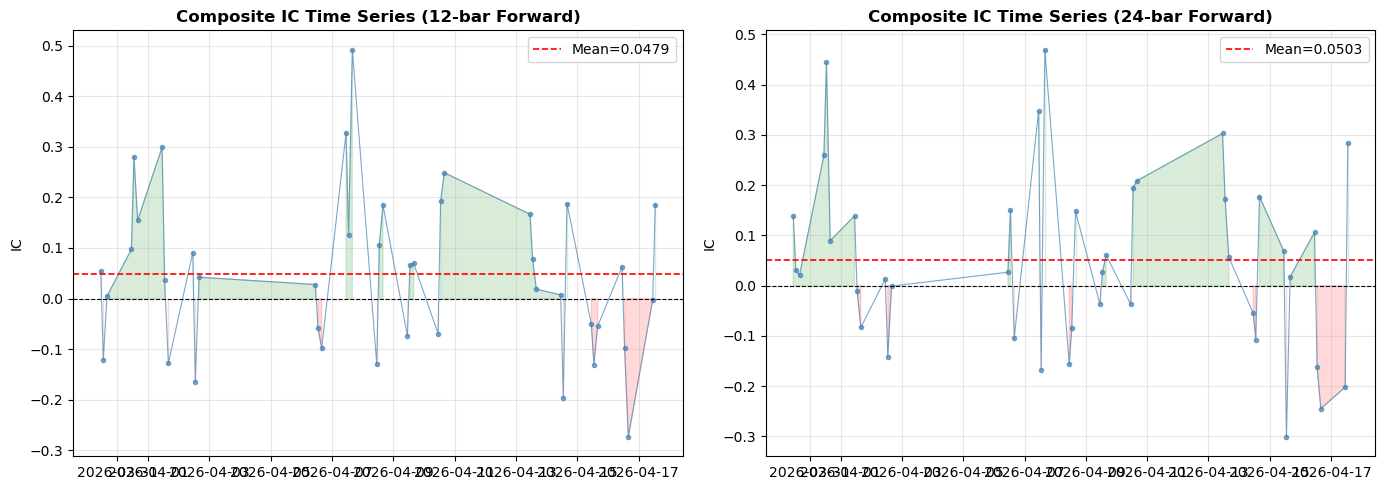

In [150]:
# ===================== IC Analysis =====================

strategy_ic = AdaptiveMultiFactorStrategy(tickers=price_data.columns.tolist(), top_k=20)

rebalance_times = [(11, 0), (13, 0), (15, 55)]
records = []

for i in range(len(price_data)):
    prices_arr = price_data.iloc[i].values
    volumes_arr = volume_data.iloc[i].values
    _ = strategy_ic.step(prices_arr, volumes_arr)
    
    ts = price_data.index[i]
    if (ts.hour, ts.minute) in rebalance_times:
        if strategy_ic.step_count >= strategy_ic.lookback_medium + 1:
            price_arr = np.array(strategy_ic.price_history)
            vol_arr = np.array(strategy_ic.volume_history)
            current_prices = price_arr[-1]
            
            past_short = price_arr[-1 - strategy_ic.lookback_short]
            ret_short = (current_prices - past_short) / (past_short + 1e-10)
            reversal_signal = -ret_short
            
            past_medium = price_arr[-1 - strategy_ic.lookback_medium]
            ret_medium = (current_prices - past_medium) / (past_medium + 1e-10)
            momentum_signal = ret_medium
            
            avg_vol = np.nanmean(vol_arr[-10:], axis=0)
            std_vol = np.nanstd(vol_arr[-10:], axis=0)
            volume_signal = (volumes_arr - avg_vol) / (std_vol + 1e-10)
            volume_signal = np.clip(volume_signal, -3, 3)
            
            spy_idx = strategy_ic.spy_idx
            spy_5bar = (price_arr[-1, spy_idx] - price_arr[-6, spy_idx]) / price_arr[-6, spy_idx] if strategy_ic.step_count >= 6 else 0
            spy_medium = ret_medium[spy_idx]
            
            if spy_5bar > 0.001 or spy_medium > 0.003:
                w_rev, w_mom, w_vol = 0.05, 0.90, 0.05
            elif spy_5bar < -0.001 or spy_medium < -0.003:
                w_rev, w_mom, w_vol = 0.80, 0.15, 0.05
            else:
                w_rev, w_mom, w_vol = 0.15, 0.80, 0.05
            
            rank_rev = AdaptiveMultiFactorStrategy._rank(reversal_signal)
            rank_mom = AdaptiveMultiFactorStrategy._rank(momentum_signal)
            rank_vol = AdaptiveMultiFactorStrategy._rank(volume_signal)
            composite = w_rev * rank_rev + w_mom * rank_mom + w_vol * rank_vol
            
            records.append({
                'timestamp': ts,
                'composite': composite,
                'reversal': reversal_signal,
                'momentum': momentum_signal,
                'volume': volume_signal,
                'price_idx': i,
            })

# Compute forward returns for each horizon
for rec in records:
    i = rec['price_idx']
    current = P[i]
    for h in [6, 12, 18, 24]:
        if i + h < len(P):
            fut_ret = (P[i + h] - current) / (current + 1e-10)
            rec[f'ret_{h}'] = fut_ret

# IC calculation
from scipy import stats

def compute_ic(factor_values, return_values):
    ics = []
    for f, r in zip(factor_values, return_values):
        valid = np.isfinite(f) & np.isfinite(r)
        if valid.sum() > 10:
            ic, _ = stats.spearmanr(f[valid], r[valid])
            if np.isfinite(ic):
                ics.append(ic)
    ics = np.array(ics)
    return {
        'mean': np.nanmean(ics),
        'std': np.nanstd(ics),
        'ir': np.nanmean(ics) / np.nanstd(ics) if np.nanstd(ics) > 0 else 0,
        'pos_pct': (ics > 0).mean() * 100,
        'n': len(ics),
        'series': ics,
    }

print("=" * 70)
print("MULTI-HORIZON INFORMATION COEFFICIENT (IC) ANALYSIS")
print("=" * 70)
print("IC measures the rank correlation between the composite score and")
print("forward returns over different holding periods.\n")

factor_names = {
    'composite': 'Composite',
    'reversal': 'Reversal',
    'momentum': 'Momentum',
    'volume': 'Volume',
}

results = {}
for factor_key in ['composite', 'reversal', 'momentum', 'volume']:
    factor_values = [rec[factor_key] for rec in records]
    results[factor_key] = {}
    for h in [6, 12, 18, 24]:
        ret_key = f'ret_{h}'
        if ret_key in records[0]:
            return_values = [rec[ret_key] for rec in records if ret_key in rec]
            # Truncate to same length
            min_len = min(len(factor_values), len(return_values))
            ic_result = compute_ic(factor_values[:min_len], return_values[:min_len])
            results[factor_key][h] = ic_result

print(f"{'Factor':<12} {'Horizon':<10} {'IC Mean':>10} {'IC Std':>10} {'IC IR':>10} {'Pos%':>8} {'N':>5}")
print("-" * 70)
for factor_key in ['composite', 'reversal', 'momentum', 'volume']:
    for h in [6, 12, 18, 24]:
        if h in results[factor_key]:
            r = results[factor_key][h]
            print(f"{factor_names[factor_key]:<12} {h}-bar      {r['mean']:>10.4f} {r['std']:>10.4f} {r['ir']:>10.4f} {r['pos_pct']:>7.1f}% {r['n']:>5}")
    print("-" * 70)

# Plot IC time series for composite at 12-bar and 24-bar
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, h in zip(axes, [12, 24]):
    ic_series = results['composite'][h]['series']
    timestamps = [rec['timestamp'] for rec in records[:len(ic_series)]]
    ax.plot(timestamps, ic_series, color='steelblue', linewidth=0.8, alpha=0.7, marker='o', markersize=3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.axhline(y=np.nanmean(ic_series), color='red', linestyle='--', linewidth=1.2, label=f"Mean={np.nanmean(ic_series):.4f}")
    ax.fill_between(timestamps, 0, ic_series, where=(ic_series >= 0), color='green', alpha=0.15)
    ax.fill_between(timestamps, 0, ic_series, where=(ic_series < 0), color='red', alpha=0.15)
    ax.set_title(f'Composite IC Time Series ({h}-bar Forward)', fontsize=12, fontweight='bold')
    ax.set_ylabel('IC')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [151]:
# ===================== Transaction Cost Simulation =====================

class Evaluator:
    def __init__(self, returns: pd.Series, periods_per_year: int = 252):
        self.returns = returns.dropna()
        self.periods_per_year = periods_per_year
    def cumulative_return(self) -> float:
        return (1 + self.returns).prod() - 1.0
    def cagr(self) -> float:
        cum_ret = self.cumulative_return()
        num_periods = self.returns.count() 
        
        if num_periods == 0:
            return 0.0
            
        return (1 + cum_ret) ** (self.periods_per_year / num_periods) - 1.0
    def annualized_volatility(self) -> float:
        return self.returns.std() * np.sqrt(self.periods_per_year)
    def sharpe_ratio(self, risk_free_rate: float = 0.0) -> float:
        """
        Calculates the annualized Sharpe Ratio.
        Mathematically, this must use the Arithmetic Mean, not the CAGR.
        """
        ann_vol = self.annualized_volatility()
        if ann_vol == 0:
            return 0.0
            
        # Calculate Arithmetic Annualized Return for the Sharpe numerator
        arithmetic_ann_ret = self.returns.mean() * self.periods_per_year
        
        return (arithmetic_ann_ret - risk_free_rate) / ann_vol
    def max_drawdown(self) -> float:
        """
        Calculates the maximum drawdown.
        Prepends 1.0 to cumulative wealth to capture drawdowns starting from the very first period.
        """
        cumulative_wealth = (1 + self.returns).cumprod()
        
        # Prepend 1.0 to represent the initial portfolio value before any trading
        wealth_with_initial = pd.concat([pd.Series([1.0]), cumulative_wealth], ignore_index=True)
        
        rolling_max = wealth_with_initial.cummax()
        drawdowns = (wealth_with_initial - rolling_max) / rolling_max
        
        return drawdowns.min()
    def generate_report(self):
        """
        Prints and returns a dictionary of all computed metrics.
        """
        metrics = {
            "Cumulative Return": f"{self.cumulative_return() * 100:.4f}%",
            "Annualized Volatility": f"{self.annualized_volatility() * 100:.4f}%",
            "Sharpe Ratio": f"{self.sharpe_ratio():.4f}",
            "Max Drawdown": f"{self.max_drawdown() * 100:.4f}%"
        }
        
        print("\n--- Strategy Performance Report ---")
        for key, value in metrics.items():
            print(f"{key:<25}: {value}")
        print("-" * 60)
        
        return metrics
TC_SCENARIOS = {
    "Low-Cost  (3 bps/side)": 3,
    "Medium-Cost (5 bps/side)": 5,
    "High-Cost (10 bps/side)": 10,
}
print("=" * 60)
print("TRANSACTION COST IMPACT ANALYSIS")
print("=" * 60)
print(f"Rebalance Frequency: 3x daily | Base Turnover: {annual_turnover:.1f}x")
for label, tc_bps in TC_SCENARIOS.items():
    tc_costs = np.zeros(len(P))
    for i in range(len(P)):
        ts = idx[i]
        if (ts.hour, ts.minute) in REBALANCE_TIMES and i > 0:
            turnover = np.sum(np.abs(weights[i] - weights[i-1]))
            tc_costs[i] = turnover * (2 * tc_bps / 10000)
    
    portfolio_returns_tc = pd.Series(
        np.nansum(weights[:-1] * ret_matrix, axis=1) - tc_costs[:-1],
        index=idx[1:]
    ).fillna(0)
    
    evaluator_tc = Evaluator(portfolio_returns_tc, periods_per_year=PERIODS_PER_YEAR)
    print(f"\n--- {label} Performance Report ---")
    metrics = evaluator_tc.generate_report()
# Turnover distribution
tc_df = pd.DataFrame({
    'Date': [d.date() for d in daily_turnover.index],
    'Daily_Turnover_%': (daily_turnover.values * 100).round(2)
})
print("--- Daily Turnover Summary (No-Cost Backtest) ---")
print(tc_df.head(10).to_string(index=False))
print(f"... ({len(tc_df)} days total)")
print("=" * 60)

TRANSACTION COST IMPACT ANALYSIS
Rebalance Frequency: 3x daily | Base Turnover: 315.1x

--- Low-Cost  (3 bps/side) Performance Report ---

--- Strategy Performance Report ---
Cumulative Return        : 12.5979%
Annualized Volatility    : 28.1639%
Sharpe Ratio             : 7.7299
Max Drawdown             : -3.6686%
------------------------------------------------------------

--- Medium-Cost (5 bps/side) Performance Report ---

--- Strategy Performance Report ---
Cumulative Return        : 11.9913%
Annualized Volatility    : 28.1318%
Sharpe Ratio             : 7.3924
Max Drawdown             : -3.6804%
------------------------------------------------------------

--- High-Cost (10 bps/side) Performance Report ---

--- Strategy Performance Report ---
Cumulative Return        : 10.4886%
Annualized Volatility    : 28.0734%
Sharpe Ratio             : 6.5402
Max Drawdown             : -3.7323%
------------------------------------------------------------
--- Daily Turnover Summary (No-Cost B